# 形状を区別した PO と光線追跡法の強度比較

`260619_1348` をオクタゴニカル形状、`260621_1559` をコニカル形状として、ガウシアン形状のほぼ平面波 ray による幾何光学的な強度を計算し、PO の `|E|^2` と比較します。

ここでの光線追跡強度は ray power density であり、位相、干渉、回折は含みません。そのため PO の絶対強度そのものではなく、主にピーク位置と分布形状の比較に使います。

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd()
VENV_DIR = (ROOT.parent / ".venv").resolve()
VENV_SITE_PACKAGES = VENV_DIR / "lib" / f"python{sys.version_info.major}.{sys.version_info.minor}" / "site-packages"

if not VENV_SITE_PACKAGES.exists():
    raise RuntimeError(f".venv の site-packages が見つかりません: {VENV_SITE_PACKAGES}")
if str(VENV_SITE_PACKAGES) not in sys.path:
    sys.path.insert(0, str(VENV_SITE_PACKAGES))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-comparison-cache")

print(f"current python : {sys.executable}")
print(f"using packages : {VENV_SITE_PACKAGES}")

current python : /home/irie/fortran/my_project/concentrator_2/.venv/bin/python
using packages : /home/irie/fortran/my_project/concentrator_2/.venv/lib/python3.12/site-packages


In [2]:
import numpy as np
import matplotlib.pyplot as plt

PI = np.pi
print("numpy     ", np.__version__)
print("matplotlib", plt.matplotlib.__version__)

numpy      2.4.6
matplotlib 3.10.9


In [3]:
RESULT_DIRS = [Path("260619_1348"), Path("260621_1559")]
LABELS = [path.name for path in RESULT_DIRS]

# ユーザー指定の形状対応。
# conical: 円錐コーン
# octagonal_faceted: 硬い8面のオクタゴナル・フラスタム近似
SHAPE_BY_RESULT = {
    "260619_1348": "octagonal_faceted",
    "260621_1559": "conical",
}

OUTDIR = Path("raytrace_shape_comparison")
OUTDIR.mkdir(exist_ok=True)

# PO 側の入射ガウシアンと同じ値。Rayleigh 長が長いため、形状内ではほぼ +z 向き平面波です。
FREQ_HZ = 94.0e9
C0 = 2.99792458e8
LAMBDA0 = C0 / FREQ_HZ
W0_SRC = 0.2
Z0_SRC = 0.0
ZR_SRC = np.pi * W0_SRC**2 / LAMBDA0
PO_INCIDENT_E2_PEAK = 1.0

# 2D 入射開口を極座標セルに分割して ray を追跡します。
N_RADIAL = 360
N_THETA = 384
MAX_REFLECTIONS = 60
RAY_RADIAL_BIN_WIDTH = 0.05e-3
RAY_AXIS_Z_STEP = 0.10e-3
AXIS_PROBE_RADIUS = 0.5e-3
INCIDENT_MATCHED_YMAX = 1000.0

print(f"lambda0 = {LAMBDA0:.6e} m")
print(f"zR      = {ZR_SRC:.6e} m")
print(f"PO incident peak |E|^2 = {PO_INCIDENT_E2_PEAK:.3f}")
print(f"rays/result = {N_RADIAL * N_THETA}")
print(f"ray radial bin width = {RAY_RADIAL_BIN_WIDTH*1e3:.3f} mm")
print("ray diameter profile = 2D XY density sampled on the PO grid")
print(f"ray axis z step      = {RAY_AXIS_Z_STEP*1e3:.3f} mm")
print(f"incident-matched plot ymax = {INCIDENT_MATCHED_YMAX:.1f}")
print(f"output  = {OUTDIR}")

lambda0 = 3.189281e-03 m
zR      = 3.940189e+01 m
PO incident peak |E|^2 = 1.000
rays/result = 138240
ray radial bin width = 0.050 mm
ray diameter profile = 2D XY density sampled on the PO grid
ray axis z step      = 0.100 mm
incident-matched plot ymax = 1000.0
output  = raytrace_shape_comparison


## PO field map の読み込み

In [4]:
def parse_geometry(path: Path) -> dict[str, float]:
    geometry = {}
    for line in path.read_text().splitlines():
        if "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.split("[", 1)[0].strip()
        try:
            geometry[key] = float(value.split()[0])
        except ValueError:
            pass
    return geometry


def parse_xy_index(path: Path):
    rows = []
    for line in path.read_text().splitlines():
        if not line.strip() or line.lstrip().startswith("#"):
            continue
        index, z_value, region = line.split()[:3]
        rows.append((int(index), float(z_value), region))
    return rows


def choose_near_exit_xy_file(result_dir: Path, geometry: dict[str, float]):
    cone_end_z = geometry["base_z"] + geometry["l_cone"]
    rows = parse_xy_index(result_dir / "xy_plane_index_to_z.txt")
    downstream = [row for row in rows if row[1] > cone_end_z + 1.0e-12]
    if downstream:
        index, z_value, region = min(downstream, key=lambda row: row[1])
    else:
        index, z_value, region = min(rows, key=lambda row: abs(row[1] - cone_end_z))
    return result_dir / f"field_map_xy_z{index:03d}.bin", z_value, cone_end_z, region


def read_field_map(path: Path):
    raw = np.fromfile(path, dtype="<f8")
    if raw.size % 4 != 0:
        raise ValueError(f"{path} は x, y, z, intensity の4平面に分けられません")
    n_points = raw.size // 4
    x, y, z, intensity = np.split(raw, 4)
    reset = np.flatnonzero(np.diff(x) <= 0)
    if reset.size == 0:
        raise ValueError(f"{path}: x 座標からグリッド幅を推定できません")
    nx = int(reset[0] + 1)
    ny = int(n_points // nx)
    shape = (ny, nx)
    return {
        "path": path,
        "nx": nx,
        "ny": ny,
        "x": x.reshape(shape),
        "y": y.reshape(shape),
        "z": z.reshape(shape),
        "intensity": intensity.reshape(shape),
    }


def radial_profile_from_xy(field_map, max_radius, bin_width=None):
    x = field_map["x"]
    y = field_map["y"]
    intensity = field_map["intensity"]
    radius = np.hypot(x, y)
    finite = np.isfinite(intensity)
    if bin_width is None:
        dx = np.diff(x[0, :])
        bin_width = np.min(dx[dx > 0])
    edges = np.arange(0.0, max_radius + bin_width, bin_width)
    index = np.digitize(radius[finite], edges) - 1
    valid = (index >= 0) & (index < len(edges) - 1)
    index = index[valid]
    values = intensity[finite][valid]
    counts = np.bincount(index, minlength=len(edges) - 1)
    sums = np.bincount(index, weights=values, minlength=len(edges) - 1)
    means = np.full(len(edges) - 1, np.nan)
    means[counts > 0] = sums[counts > 0] / counts[counts > 0]
    if np.any(counts > 0):
        last = np.flatnonzero(counts > 0)[-1] + 1
        edges = edges[: last + 1]
        means = means[:last]
        counts = counts[:last]
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, edges, means, counts


def diameter_profile_from_grid(x_axis, y_axis, values):
    x_axis = np.asarray(x_axis, dtype=float)
    y_axis = np.asarray(y_axis, dtype=float)
    values = np.asarray(values, dtype=float)
    line_i = np.array([np.interp(0.0, y_axis, values[:, j]) for j in range(values.shape[1])])
    return x_axis, line_i


def diameter_profile_from_xy(field_map):
    return diameter_profile_from_grid(
        field_map["x"][0, :],
        field_map["y"][:, 0],
        field_map["intensity"],
    )


def cell_edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    if centers.ndim != 1 or centers.size < 2:
        raise ValueError("cell edge estimation needs a 1D axis with at least two points")
    if not np.all(np.diff(centers) > 0.0):
        raise ValueError("grid centers must be strictly increasing")
    mid = 0.5 * (centers[:-1] + centers[1:])
    first = centers[0] - (mid[0] - centers[0])
    last = centers[-1] + (centers[-1] - mid[-1])
    return np.concatenate(([first], mid, [last]))


def xy_cell_area_from_axes(x_axis, y_axis):
    x_edges = cell_edges_from_centers(x_axis)
    y_edges = cell_edges_from_centers(y_axis)
    return np.abs(np.diff(y_edges))[:, None] * np.abs(np.diff(x_edges))[None, :]


def axis_profile_from_xz(field_map):
    x_axis = field_map["x"][0, :]
    z_axis = field_map["z"][:, 0]
    intensity = field_map["intensity"]
    axis_i = np.array([np.interp(0.0, x_axis, row) for row in intensity])
    return z_axis, axis_i


def normalize_profile(values):
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak == 0.0:
        return values * np.nan
    return values / peak


def interp_profile(x_source, values, x_target):
    return np.interp(x_target, x_source, values, left=np.nan, right=np.nan)

In [5]:
po_profiles = []

for result_dir, label in zip(RESULT_DIRS, LABELS):
    geometry = parse_geometry(result_dir / "geometry_summary.txt")
    xy_file, xy_z, cone_end_z, xy_region = choose_near_exit_xy_file(result_dir, geometry)
    xy_map = read_field_map(xy_file)
    xz_map = read_field_map(result_dir / "field_map_xz.bin")

    r_centers, r_edges, radial_mean, radial_count = radial_profile_from_xy(
        xy_map,
        max_radius=geometry["r_pipe"],
    )
    xy_x_axis = xy_map["x"][0, :]
    xy_y_axis = xy_map["y"][:, 0]
    diameter_x, diameter_i = diameter_profile_from_grid(xy_x_axis, xy_y_axis, xy_map["intensity"])
    z_axis, axis_i = axis_profile_from_xz(xz_map)

    po_profiles.append({
        "label": label,
        "shape": SHAPE_BY_RESULT[label],
        "result_dir": result_dir,
        "geometry": geometry,
        "xy_file": xy_file,
        "xy_z": xy_z,
        "xy_region": xy_region,
        "cone_end_z": cone_end_z,
        "r_centers": r_centers,
        "r_edges": r_edges,
        "radial_mean": radial_mean,
        "radial_count": radial_count,
        "xy_x_axis": xy_x_axis,
        "xy_y_axis": xy_y_axis,
        "diameter_x": diameter_x,
        "diameter_i": diameter_i,
        "z_axis": z_axis,
        "axis_i": axis_i,
    })

for profile in po_profiles:
    offset_mm = (profile["xy_z"] - profile["cone_end_z"]) * 1e3
    print(f"{profile['label']}: shape={profile['shape']}, profile z={profile['xy_z']:.6f} m ({offset_mm:.3f} mm after cone end), selected {profile['xy_file']}")

260619_1348: shape=octagonal_faceted, profile z=0.376667 m (16.667 mm after cone end), selected 260619_1348/field_map_xy_z021.bin
260621_1559: shape=conical, profile z=0.376667 m (16.667 mm after cone end), selected 260621_1559/field_map_xy_z009.bin


## 形状対応 ray tracing

`octagonal_faceted` は硬い8角形フラスタム近似です。Fortran 側の soft-octagon-to-circle 遷移を完全再現したものではありませんが、オクタゴナル形状による幾何光学的な集光傾向を調べるための高速モデルです。

In [6]:
def make_trace_geometry(geometry):
    base_z = geometry["base_z"]
    r_cone_in = geometry["r_cone_in"]
    r_pipe = geometry["r_pipe"]
    l_cone = geometry["l_cone"]
    l_pipe = geometry["l_pipe"]
    f_cap = geometry["f_cap"]
    z_cone_end = base_z + l_cone
    z_pipe_end = base_z + l_cone + l_pipe
    z_cap_vertex = z_pipe_end + r_pipe**2 / (4.0 * f_cap)
    return {
        "base_z": base_z,
        "r_cone_in": r_cone_in,
        "r_pipe": r_pipe,
        "l_cone": l_cone,
        "l_pipe": l_pipe,
        "f_cap": f_cap,
        "z_cone_end": z_cone_end,
        "z_pipe_end": z_pipe_end,
        "z_cap_vertex": z_cap_vertex,
        "cone_slope": (r_pipe - r_cone_in) / l_cone,
    }


def gaussian_intensity_on_source_plane(radius, z, w0=W0_SRC, z0=Z0_SRC, zR=ZR_SRC):
    dz = z - z0
    wz = w0 * np.sqrt(1.0 + (dz / zR) ** 2)
    return PO_INCIDENT_E2_PEAK * (w0 / wz) ** 2 * np.exp(-2.0 * radius**2 / wz**2)


def octagonal_aperture_radius(theta, r_vertex):
    normals = PI / 8.0 + np.arange(8) * PI / 4.0
    support = r_vertex * np.cos(PI / 8.0)
    return support / np.max(np.cos(theta - normals))


def aperture_radius(theta, geom, shape):
    if shape == "octagonal_faceted":
        return octagonal_aperture_radius(theta, geom["r_cone_in"])
    return geom["r_cone_in"]


def point_in_aperture(x, y, geom, shape):
    radius = np.hypot(x, y)
    if radius < 1.0e-15:
        return True
    theta = np.arctan2(y, x)
    return radius <= aperture_radius(theta, geom, shape) + 1.0e-8


def wall_radius_for_plot(theta, z, geom, shape):
    z = np.asarray(z)
    radius = np.full_like(z, np.nan, dtype=float)
    cone = (z >= geom["base_z"]) & (z <= geom["z_cone_end"])
    pipe = (z > geom["z_cone_end"]) & (z <= geom["z_pipe_end"])
    cap = (z > geom["z_pipe_end"]) & (z <= geom["z_cap_vertex"])
    r_ref = geom["r_cone_in"] + geom["cone_slope"] * (z[cone] - geom["base_z"])
    if shape == "octagonal_faceted":
        radius[cone] = octagonal_aperture_radius(theta, r_ref)
    else:
        radius[cone] = r_ref
    radius[pipe] = geom["r_pipe"]
    arg = geom["r_pipe"] ** 2 - 4.0 * geom["f_cap"] * (z[cap] - geom["z_pipe_end"])
    radius[cap] = np.sqrt(np.maximum(arg, 0.0))
    return radius


def reflect(direction, normal):
    return direction - 2.0 * np.dot(direction, normal) * normal

In [7]:
def hit_conical_cone(point, direction, geom):
    eps = 1.0e-9
    slope = geom["cone_slope"]
    r0 = geom["r_cone_in"] - slope * geom["base_z"]
    x, y, z = point
    dx, dy, dz = direction
    R = r0 + slope * z
    A = dx * dx + dy * dy - (slope * dz) ** 2
    B = 2.0 * (x * dx + y * dy - R * slope * dz)
    C = x * x + y * y - R * R
    roots = []
    if abs(A) < 1.0e-18:
        if abs(B) > 1.0e-18:
            roots.append(-C / B)
    else:
        disc = B * B - 4.0 * A * C
        if disc >= 0.0:
            sqrt_disc = np.sqrt(disc)
            roots.extend([(-B - sqrt_disc) / (2.0 * A), (-B + sqrt_disc) / (2.0 * A)])
    candidates = []
    for t in roots:
        if t <= eps:
            continue
        hit = point + t * direction
        if geom["base_z"] - 1.0e-9 <= hit[2] <= geom["z_cone_end"] + 1.0e-9:
            rho = np.hypot(hit[0], hit[1])
            normal = np.array([hit[0] / rho, hit[1] / rho, -slope])
            normal /= np.linalg.norm(normal)
            candidates.append((t, "cone", normal))
    return min(candidates, key=lambda item: item[0]) if candidates else None


def hit_octagonal_cone(point, direction, geom):
    eps = 1.0e-9
    normals = PI / 8.0 + np.arange(8) * PI / 4.0
    cos_normals = np.cos(normals)
    sin_normals = np.sin(normals)
    support0 = geom["r_cone_in"] * np.cos(PI / 8.0)
    support_slope = (geom["r_pipe"] - geom["r_cone_in"]) * np.cos(PI / 8.0) / geom["l_cone"]
    candidates = []

    for nx, ny in zip(cos_normals, sin_normals):
        denom = nx * direction[0] + ny * direction[1] - support_slope * direction[2]
        if abs(denom) < 1.0e-14:
            continue
        support_here = support0 + support_slope * (point[2] - geom["base_z"])
        t = (support_here - nx * point[0] - ny * point[1]) / denom
        if t <= eps:
            continue
        hit = point + t * direction
        if not (geom["base_z"] - 1.0e-9 <= hit[2] <= geom["z_cone_end"] + 1.0e-9):
            continue
        support_at_hit = support0 + support_slope * (hit[2] - geom["base_z"])
        all_face_values = cos_normals * hit[0] + sin_normals * hit[1]
        if np.all(all_face_values <= support_at_hit + 1.0e-7):
            normal = np.array([nx, ny, -support_slope])
            normal /= np.linalg.norm(normal)
            candidates.append((t, "cone", normal))
    return min(candidates, key=lambda item: item[0]) if candidates else None


def hit_pipe(point, direction, geom):
    eps = 1.0e-9
    x, y, z = point
    dx, dy, dz = direction
    A = dx * dx + dy * dy
    if A < 1.0e-18:
        return None
    B = 2.0 * (x * dx + y * dy)
    C = x * x + y * y - geom["r_pipe"] ** 2
    disc = B * B - 4.0 * A * C
    if disc < 0.0:
        return None
    candidates = []
    sqrt_disc = np.sqrt(disc)
    for t in [(-B - sqrt_disc) / (2.0 * A), (-B + sqrt_disc) / (2.0 * A)]:
        if t <= eps:
            continue
        hit = point + t * direction
        if geom["z_cone_end"] - 1.0e-9 <= hit[2] <= geom["z_pipe_end"] + 1.0e-9:
            normal = np.array([hit[0], hit[1], 0.0])
            normal /= np.linalg.norm(normal)
            candidates.append((t, "pipe", normal))
    return min(candidates, key=lambda item: item[0]) if candidates else None


def hit_cap(point, direction, geom):
    eps = 1.0e-9
    x, y, z = point
    dx, dy, dz = direction
    f = geom["f_cap"]
    rp = geom["r_pipe"]
    zpe = geom["z_pipe_end"]
    A = (dx * dx + dy * dy) / (4.0 * f)
    B = dz + (x * dx + y * dy) / (2.0 * f)
    C = z - zpe - (rp * rp - x * x - y * y) / (4.0 * f)
    roots = []
    if abs(A) < 1.0e-18:
        if abs(B) > 1.0e-18:
            roots.append(-C / B)
    else:
        disc = B * B - 4.0 * A * C
        if disc >= 0.0:
            sqrt_disc = np.sqrt(disc)
            roots.extend([(-B - sqrt_disc) / (2.0 * A), (-B + sqrt_disc) / (2.0 * A)])
    candidates = []
    for t in roots:
        if t <= eps:
            continue
        hit = point + t * direction
        rho = np.hypot(hit[0], hit[1])
        if rho <= rp + 1.0e-8 and zpe - 1.0e-9 <= hit[2] <= geom["z_cap_vertex"] + 1.0e-9:
            normal = np.array([hit[0] / (2.0 * f), hit[1] / (2.0 * f), 1.0])
            normal /= np.linalg.norm(normal)
            candidates.append((t, "cap", normal))
    return min(candidates, key=lambda item: item[0]) if candidates else None


def next_hit(point, direction, geom, shape):
    candidates = []
    eps = 1.0e-9

    if direction[2] < -1.0e-14:
        t = (geom["base_z"] - point[2]) / direction[2]
        if t > eps:
            hit = point + t * direction
            if point_in_aperture(hit[0], hit[1], geom, shape):
                candidates.append((t, "exit", None))

    cone_hit = hit_conical_cone(point, direction, geom) if shape == "conical" else hit_octagonal_cone(point, direction, geom)
    if cone_hit is not None:
        candidates.append(cone_hit)
    pipe_hit = hit_pipe(point, direction, geom)
    if pipe_hit is not None:
        candidates.append(pipe_hit)
    cap_hit = hit_cap(point, direction, geom)
    if cap_hit is not None:
        candidates.append(cap_hit)

    if not candidates:
        return None
    return min(candidates, key=lambda item: item[0])

In [8]:
def trace_rays(geom, shape, n_radial=N_RADIAL, n_theta=N_THETA, max_reflections=MAX_REFLECTIONS):
    theta_centers = (np.arange(n_theta) + 0.5) * 2.0 * PI / n_theta
    dtheta = 2.0 * PI / n_theta
    shift = 1.0e-8
    segments = []
    hit_counts = {"cone": 0, "pipe": 0, "cap": 0, "exit": 0, "lost": 0, "maxed": 0}
    total_power = 0.0
    ray_id = 0

    for theta in theta_centers:
        r_ap = aperture_radius(theta, geom, shape)
        r_edges = np.linspace(0.0, r_ap, n_radial + 1)
        r_centers = 0.5 * (r_edges[:-1] + r_edges[1:])
        cell_areas = 0.5 * (r_edges[1:] ** 2 - r_edges[:-1] ** 2) * dtheta
        weights = gaussian_intensity_on_source_plane(r_centers, geom["base_z"]) * cell_areas
        total_power += weights.sum()

        cth = np.cos(theta)
        sth = np.sin(theta)
        for radius, weight in zip(r_centers, weights):
            point = np.array([radius * cth, radius * sth, geom["base_z"] + shift], dtype=float)
            direction = np.array([0.0, 0.0, 1.0], dtype=float)

            for order in range(max_reflections):
                hit = next_hit(point, direction, geom, shape)
                if hit is None:
                    hit_counts["lost"] += 1
                    break
                distance, kind, normal = hit
                next_point = point + distance * direction
                segments.append([
                    point[0], point[1], point[2],
                    next_point[0], next_point[1], next_point[2],
                    weight, ray_id, order,
                ])
                hit_counts[kind] += 1
                if kind == "exit":
                    break
                direction = reflect(direction, normal)
                direction /= np.linalg.norm(direction)
                point = next_point + shift * direction
            else:
                hit_counts["maxed"] += 1
            ray_id += 1

    return np.asarray(segments, dtype=float), hit_counts, total_power


def ray_crossings_at_z(segments, z_value):
    z0 = segments[:, 2]
    z1 = segments[:, 5]
    dz = z1 - z0
    z_min = np.minimum(z0, z1)
    z_max = np.maximum(z0, z1)
    mask = (np.abs(dz) > 1.0e-14) & (z_value >= z_min - 1.0e-12) & (z_value < z_max - 1.0e-12)
    t = (z_value - z0[mask]) / dz[mask]
    x = segments[mask, 0] + t * (segments[mask, 3] - segments[mask, 0])
    y = segments[mask, 1] + t * (segments[mask, 4] - segments[mask, 1])
    weights = segments[mask, 6]
    return x, y, weights


def ray_radial_density_on_plane(segments, z_value, radial_edges):
    x, y, weights = ray_crossings_at_z(segments, z_value)
    radius = np.hypot(x, y)
    power, _ = np.histogram(radius, bins=radial_edges, weights=weights)
    counts, _ = np.histogram(radius, bins=radial_edges)
    area = np.pi * (radial_edges[1:] ** 2 - radial_edges[:-1] ** 2)
    return power / area, counts


def ray_xy_density_on_plane(segments, z_value, x_axis, y_axis):
    x_edges = cell_edges_from_centers(x_axis)
    y_edges = cell_edges_from_centers(y_axis)
    x, y, weights = ray_crossings_at_z(segments, z_value)
    power, _, _ = np.histogram2d(y, x, bins=[y_edges, x_edges], weights=weights)
    counts, _, _ = np.histogram2d(y, x, bins=[y_edges, x_edges])
    area = xy_cell_area_from_axes(x_axis, y_axis)
    density = np.divide(power, area, out=np.zeros_like(power), where=area > 0.0)
    return density, counts.astype(int), power.sum(), weights.sum()


def ray_axis_density(segments, z_axis, probe_radius=AXIS_PROBE_RADIUS):
    area = np.pi * probe_radius**2
    z_axis = np.asarray(z_axis, dtype=float)
    density_diff = np.zeros(len(z_axis) + 1, dtype=float)
    count_diff = np.zeros(len(z_axis) + 1, dtype=int)

    z0 = segments[:, 2]
    z1 = segments[:, 5]
    dz = z1 - z0
    active = np.abs(dz) > 1.0e-14

    x0 = segments[active, 0]
    y0 = segments[active, 1]
    z0 = z0[active]
    dz = dz[active]
    dx = segments[active, 3] - x0
    dy = segments[active, 4] - y0
    weights = segments[active, 6]

    radius2 = probe_radius**2
    a = dx * dx + dy * dy
    b = 2.0 * (x0 * dx + y0 * dy)
    c = x0 * x0 + y0 * y0 - radius2

    t_start = np.zeros_like(a)
    t_end = np.zeros_like(a)
    selected = np.zeros_like(a, dtype=bool)

    nearly_parallel = a <= 1.0e-30
    inside_parallel = nearly_parallel & (c <= 0.0)
    t_start[inside_parallel] = 0.0
    t_end[inside_parallel] = 1.0
    selected |= inside_parallel

    curved = ~nearly_parallel
    disc = b * b - 4.0 * a * c
    hit = curved & (disc >= 0.0)
    sqrt_disc = np.zeros_like(a)
    sqrt_disc[hit] = np.sqrt(disc[hit])
    root1 = np.zeros_like(a)
    root2 = np.zeros_like(a)
    root1[hit] = (-b[hit] - sqrt_disc[hit]) / (2.0 * a[hit])
    root2[hit] = (-b[hit] + sqrt_disc[hit]) / (2.0 * a[hit])
    lo = np.maximum(np.minimum(root1, root2), 0.0)
    hi = np.minimum(np.maximum(root1, root2), 1.0)
    inside_curved = hit & (hi > lo)
    t_start[inside_curved] = lo[inside_curved]
    t_end[inside_curved] = hi[inside_curved]
    selected |= inside_curved

    if not np.any(selected):
        return density_diff[:-1], count_diff[:-1]

    z_a = z0[selected] + dz[selected] * t_start[selected]
    z_b = z0[selected] + dz[selected] * t_end[selected]
    z_low = np.minimum(z_a, z_b)
    z_high = np.maximum(z_a, z_b)
    start = np.searchsorted(z_axis, z_low - 1.0e-12, side="left")
    end = np.searchsorted(z_axis, z_high - 1.0e-12, side="left")
    valid = (start < end) & (end > 0) & (start < len(z_axis))
    start = np.clip(start[valid], 0, len(z_axis))
    end = np.clip(end[valid], 0, len(z_axis))
    selected_weights = weights[selected][valid]

    np.add.at(density_diff, start, selected_weights / area)
    np.add.at(density_diff, end, -selected_weights / area)
    np.add.at(count_diff, start, 1)
    np.add.at(count_diff, end, -1)
    return np.cumsum(density_diff[:-1]), np.cumsum(count_diff[:-1])

In [9]:
trace_profiles = []
common_z_axis = po_profiles[0]["z_axis"]
ray_z_axis = np.arange(common_z_axis[0], common_z_axis[-1] + 0.5 * RAY_AXIS_Z_STEP, RAY_AXIS_Z_STEP)
max_pipe_radius = max(profile["geometry"]["r_pipe"] for profile in po_profiles)
ray_radial_edges = np.arange(0.0, max_pipe_radius + RAY_RADIAL_BIN_WIDTH, RAY_RADIAL_BIN_WIDTH)
ray_radial_centers = 0.5 * (ray_radial_edges[:-1] + ray_radial_edges[1:])

for profile in po_profiles:
    geom = make_trace_geometry(profile["geometry"])
    shape = profile["shape"]
    segments, hit_counts, total_power = trace_rays(geom, shape)
    radial_density, radial_counts = ray_radial_density_on_plane(
        segments,
        profile["xy_z"],
        ray_radial_edges,
    )
    xy_density, xy_counts, xy_density_integral, xy_crossing_weight = ray_xy_density_on_plane(
        segments,
        profile["xy_z"],
        profile["xy_x_axis"],
        profile["xy_y_axis"],
    )
    diameter_x, diameter_density = diameter_profile_from_grid(
        profile["xy_x_axis"],
        profile["xy_y_axis"],
        xy_density,
    )
    _, diameter_counts = diameter_profile_from_grid(
        profile["xy_x_axis"],
        profile["xy_y_axis"],
        xy_counts,
    )
    axis_density, axis_counts = ray_axis_density(segments, ray_z_axis)

    trace_profiles.append({
        "label": profile["label"],
        "shape": shape,
        "geom": geom,
        "segments": segments,
        "hit_counts": hit_counts,
        "total_power": total_power,
        "r_centers": ray_radial_centers,
        "r_edges": ray_radial_edges,
        "radial_density": radial_density,
        "radial_counts": radial_counts,
        "xy_density": xy_density,
        "xy_counts": xy_counts,
        "xy_density_integral": xy_density_integral,
        "xy_crossing_weight": xy_crossing_weight,
        "diameter_x": diameter_x,
        "diameter_density": diameter_density,
        "diameter_counts": diameter_counts,
        "z_axis": ray_z_axis,
        "axis_density": axis_density,
        "axis_counts": axis_counts,
    })

    r_centers = ray_radial_centers
    print(f"{profile['label']} ({shape})")
    print(f"  segments        = {len(segments)}")
    print(f"  total ray power = {total_power:.6e}")
    print(f"  xy-grid integral = {xy_density_integral:.6e}")
    print(f"  xy crossing sum  = {xy_crossing_weight:.6e}")
    print(f"  hit counts      = {hit_counts}")
    print(f"  radial peak     = {np.nanmax(radial_density):.6e} at r={r_centers[np.nanargmax(radial_density)]*1e3:.3f} mm")
    print(f"  diameter peak   = {np.nanmax(diameter_density):.6e} at x={diameter_x[np.nanargmax(diameter_density)]*1e3:.3f} mm")
    print(f"  axis peak       = {np.nanmax(axis_density):.6e} at z={ray_z_axis[np.nanargmax(axis_density)]*1e3:.3f} mm")

260619_1348 (octagonal_faceted)
  segments        = 855360
  total ray power = 1.919058e-02
  xy-grid integral = 3.161478e-02
  xy crossing sum  = 3.161478e-02
  hit counts      = {'cone': 275552, 'pipe': 307344, 'cap': 144400, 'exit': 128064, 'lost': 10144, 'maxed': 32}
  radial peak     = 3.131918e+02 at r=0.025 mm
  diameter peak   = 2.647358e+02 at x=0.000 mm
  axis peak       = 2.754738e+03 at z=410.000 mm


260621_1559 (conical)
  segments        = 847488
  total ray power = 2.092404e-02
  xy-grid integral = 3.040980e-02
  xy crossing sum  = 3.040980e-02
  hit counts      = {'cone': 246528, 'pipe': 330240, 'cap': 133248, 'exit': 137472, 'lost': 0, 'maxed': 768}
  radial peak     = 1.046525e+04 at r=0.025 mm
  diameter peak   = 3.834618e+03 at x=0.000 mm
  axis peak       = 3.477089e+03 at z=410.000 mm


## 規格化比較

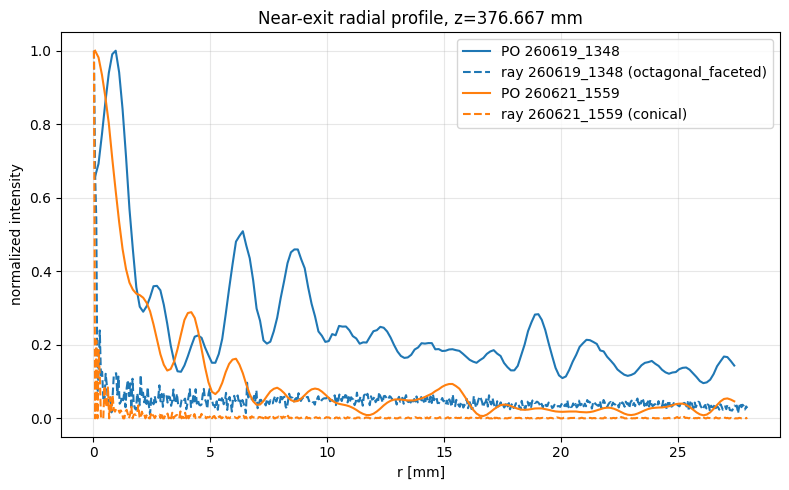

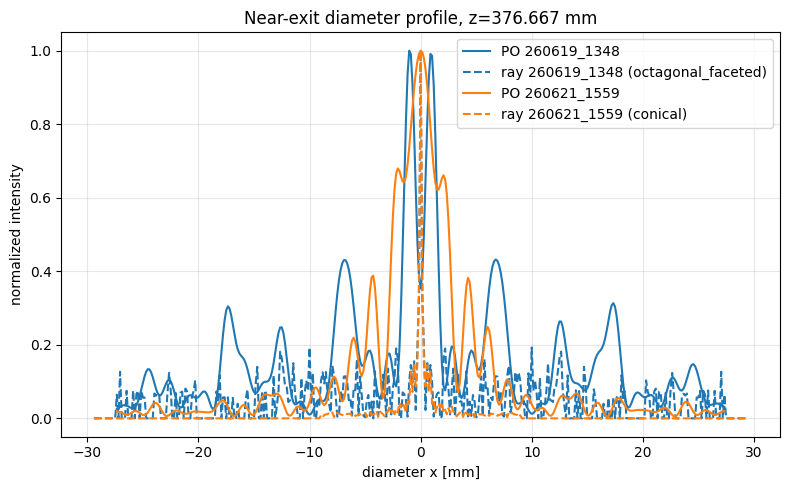

In [10]:
colors = {"260619_1348": "#1f77b4", "260621_1559": "#ff7f0e"}

plt.figure(figsize=(8, 5))
for po, rt in zip(po_profiles, trace_profiles):
    color = colors.get(po["label"], None)
    plt.plot(po["r_centers"] * 1e3, normalize_profile(po["radial_mean"]), color=color, label=f"PO {po['label']}")
    plt.plot(rt["r_centers"] * 1e3, normalize_profile(rt["radial_density"]), "--", color=color, label=f"ray {po['label']} ({rt['shape']})")
plt.xlabel("r [mm]")
plt.ylabel("normalized intensity")
plt.title(f"Near-exit radial profile, z={po_profiles[0]['xy_z']*1e3:.3f} mm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "radial_normalized_shape_aware_raytrace_vs_po.svg")
plt.show()

plt.figure(figsize=(8, 5))
for po, rt in zip(po_profiles, trace_profiles):
    color = colors.get(po["label"], None)
    mask = np.abs(po["diameter_x"]) <= po["geometry"]["r_pipe"]
    plt.plot(po["diameter_x"][mask] * 1e3, normalize_profile(po["diameter_i"][mask]), color=color, label=f"PO {po['label']}")
    plt.plot(rt["diameter_x"] * 1e3, normalize_profile(rt["diameter_density"]), "--", color=color, label=f"ray {po['label']} ({rt['shape']})")
plt.xlabel("diameter x [mm]")
plt.ylabel("normalized intensity")
plt.title(f"Near-exit diameter profile, z={po_profiles[0]['xy_z']*1e3:.3f} mm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "diameter_normalized_shape_aware_raytrace_vs_po.svg")
plt.show()

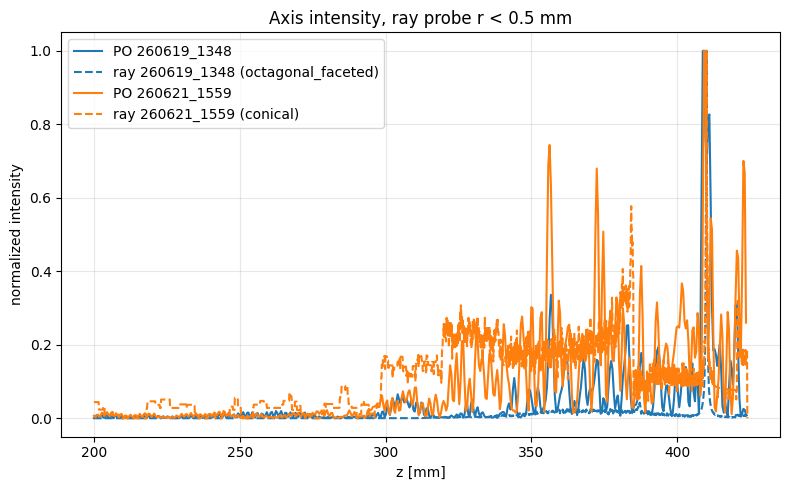

In [11]:
plt.figure(figsize=(8, 5))
for po, rt in zip(po_profiles, trace_profiles):
    color = colors.get(po["label"], None)
    plt.plot(po["z_axis"] * 1e3, normalize_profile(po["axis_i"]), color=color, label=f"PO {po['label']}")
    plt.plot(rt["z_axis"] * 1e3, normalize_profile(rt["axis_density"]), "--", color=color, label=f"ray {po['label']} ({rt['shape']})")
plt.xlabel("z [mm]")
plt.ylabel("normalized intensity")
plt.title(f"Axis intensity, ray probe r < {AXIS_PROBE_RADIUS*1e3:.1f} mm")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(OUTDIR / "axis_normalized_shape_aware_raytrace_vs_po.svg")
plt.show()

## 入射強度を揃えた比較

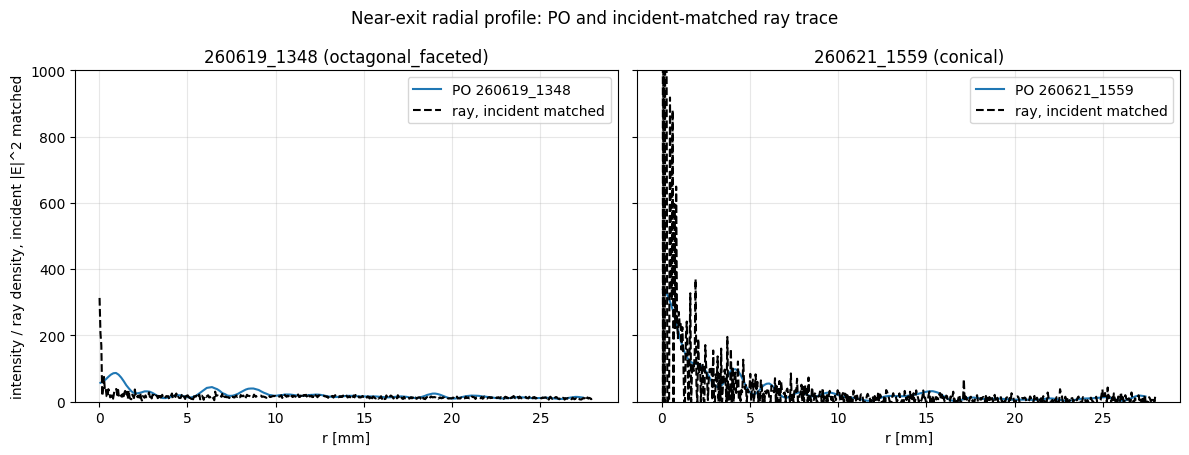

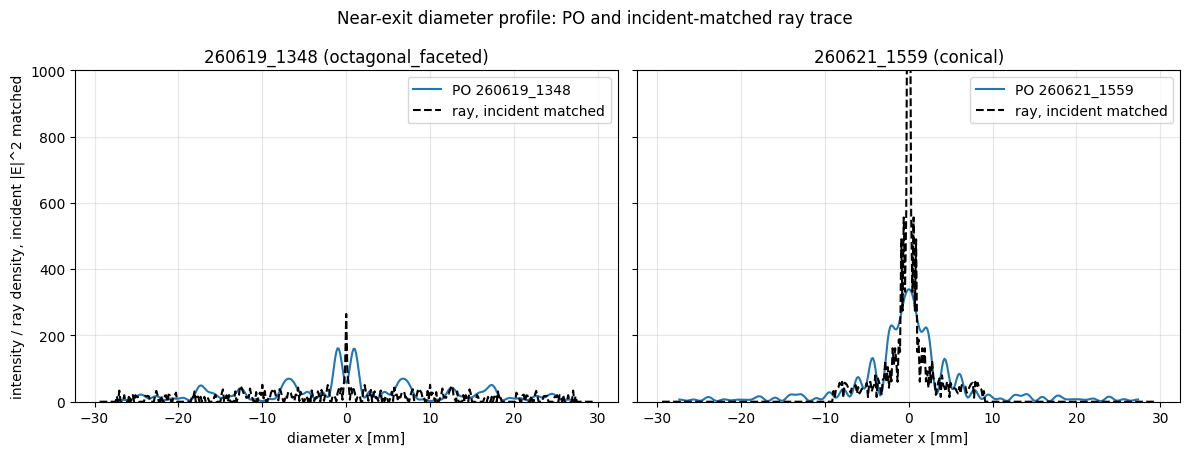

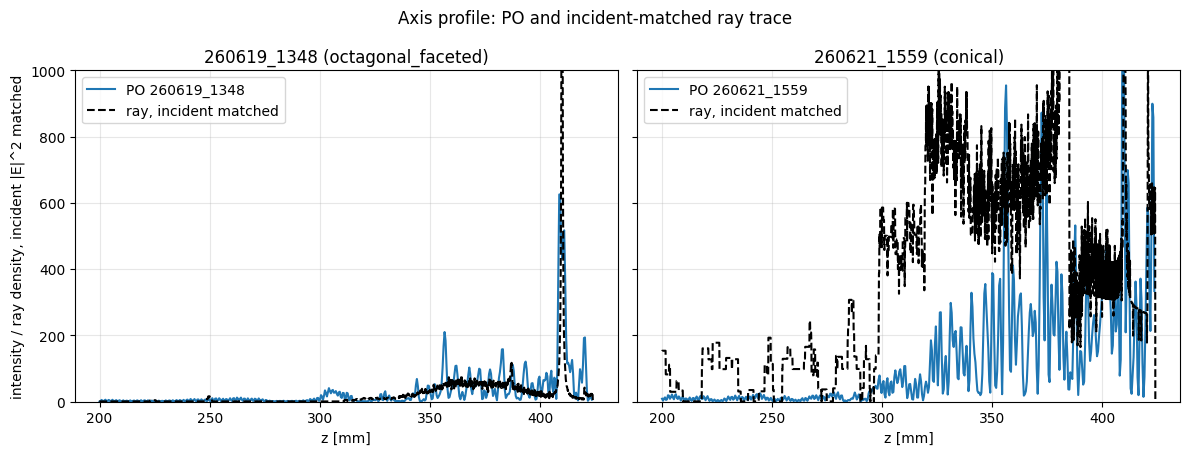

In [12]:
fig, axes = plt.subplots(1, len(po_profiles), figsize=(6 * len(po_profiles), 4.6), sharex=True, sharey=True)
if len(po_profiles) == 1:
    axes = [axes]

for ax, po, rt in zip(axes, po_profiles, trace_profiles):
    ax.plot(po["r_centers"] * 1e3, po["radial_mean"], label=f"PO {po['label']}")
    ax.plot(rt["r_centers"] * 1e3, rt["radial_density"], "k--", label="ray, incident matched")
    ax.set_title(f"{po['label']} ({rt['shape']})")
    ax.set_xlabel("r [mm]")
    ax.set_ylim(0.0, INCIDENT_MATCHED_YMAX)
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("intensity / ray density, incident |E|^2 matched")
fig.suptitle("Near-exit radial profile: PO and incident-matched ray trace")
fig.tight_layout()
fig.savefig(OUTDIR / "radial_incident_matched_shape_aware_raytrace_vs_po.svg")
plt.show()

fig, axes = plt.subplots(1, len(po_profiles), figsize=(6 * len(po_profiles), 4.6), sharex=True, sharey=True)
if len(po_profiles) == 1:
    axes = [axes]

for ax, po, rt in zip(axes, po_profiles, trace_profiles):
    mask = np.abs(po["diameter_x"]) <= po["geometry"]["r_pipe"]
    ax.plot(po["diameter_x"][mask] * 1e3, po["diameter_i"][mask], label=f"PO {po['label']}")
    ax.plot(rt["diameter_x"] * 1e3, rt["diameter_density"], "k--", label="ray, incident matched")
    ax.set_title(f"{po['label']} ({rt['shape']})")
    ax.set_xlabel("diameter x [mm]")
    ax.set_ylim(0.0, INCIDENT_MATCHED_YMAX)
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("intensity / ray density, incident |E|^2 matched")
fig.suptitle("Near-exit diameter profile: PO and incident-matched ray trace")
fig.tight_layout()
fig.savefig(OUTDIR / "diameter_incident_matched_shape_aware_raytrace_vs_po.svg")
plt.show()

fig, axes = plt.subplots(1, len(po_profiles), figsize=(6 * len(po_profiles), 4.6), sharex=True, sharey=True)
if len(po_profiles) == 1:
    axes = [axes]

for ax, po, rt in zip(axes, po_profiles, trace_profiles):
    ax.plot(po["z_axis"] * 1e3, po["axis_i"], label=f"PO {po['label']}")
    ax.plot(rt["z_axis"] * 1e3, rt["axis_density"], "k--", label="ray, incident matched")
    ax.set_title(f"{po['label']} ({rt['shape']})")
    ax.set_xlabel("z [mm]")
    ax.set_ylim(0.0, INCIDENT_MATCHED_YMAX)
    ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("intensity / ray density, incident |E|^2 matched")
fig.suptitle("Axis profile: PO and incident-matched ray trace")
fig.tight_layout()
fig.savefig(OUTDIR / "axis_incident_matched_shape_aware_raytrace_vs_po.svg")
plt.show()

## ray path の確認

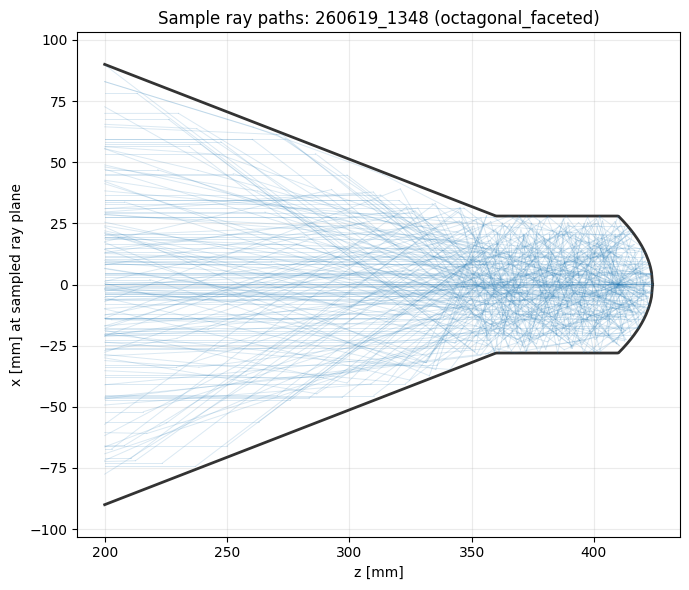

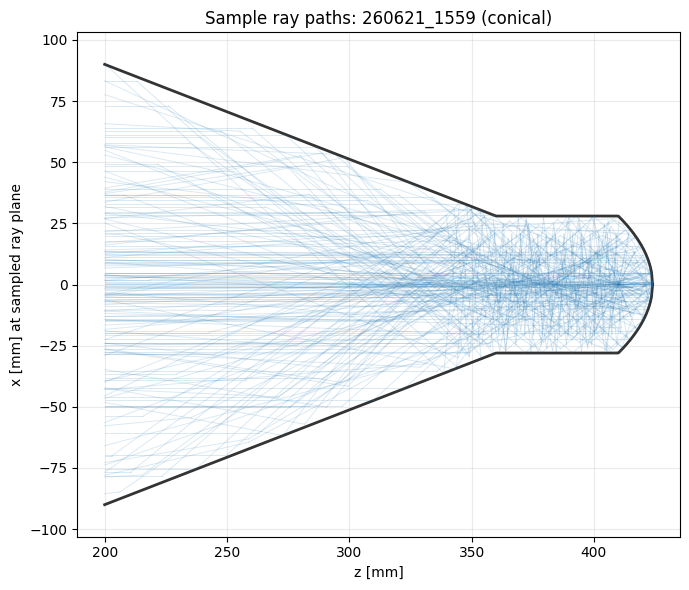

In [13]:
for po, rt in zip(po_profiles, trace_profiles):
    geom = rt["geom"]
    shape = rt["shape"]
    segments = rt["segments"]
    z_wall = np.linspace(geom["base_z"], geom["z_cap_vertex"], 500)
    r_wall = wall_radius_for_plot(0.0, z_wall, geom, shape)

    plt.figure(figsize=(7, 6))
    plt.plot(z_wall * 1e3, r_wall * 1e3, color="0.2", linewidth=2)
    plt.plot(z_wall * 1e3, -r_wall * 1e3, color="0.2", linewidth=2)
    ray_ids = np.unique(segments[:, 7].astype(int))
    sample_ids = np.linspace(ray_ids.min(), ray_ids.max(), 90, dtype=int)
    for ray_id in sample_ids:
        ray_segments = segments[segments[:, 7].astype(int) == ray_id]
        for seg in ray_segments:
            plt.plot([seg[2] * 1e3, seg[5] * 1e3], [seg[0] * 1e3, seg[3] * 1e3], color="#1f77b4", alpha=0.16, linewidth=0.7)

    plt.xlabel("z [mm]")
    plt.ylabel("x [mm] at sampled ray plane")
    plt.title(f"Sample ray paths: {po['label']} ({shape})")
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(OUTDIR / f"sample_ray_paths_{po['label']}.svg")
    plt.show()

## CSV と summary の保存

In [14]:
radial_columns = [ray_radial_centers, ray_radial_centers * 1e3]
radial_header = ["r_m", "r_mm"]
for po, rt in zip(po_profiles, trace_profiles):
    po_on_ray = interp_profile(po["r_centers"], po["radial_mean"], ray_radial_centers)
    radial_columns += [po_on_ray, normalize_profile(po_on_ray), rt["radial_density"], normalize_profile(rt["radial_density"]), rt["radial_counts"]]
    radial_header += [
        f"PO_{po['label']}_mean",
        f"PO_{po['label']}_norm",
        f"ray_{po['label']}_density",
        f"ray_{po['label']}_norm",
        f"ray_{po['label']}_count",
    ]
np.savetxt(
    OUTDIR / "radial_shape_aware_raytrace_vs_po.csv",
    np.column_stack(radial_columns),
    delimiter=",",
    header=",".join(radial_header),
    comments="",
)

diameter_x_grid = po_profiles[0]["diameter_x"]
diameter_columns = [diameter_x_grid, diameter_x_grid * 1e3]
diameter_header = ["x_m", "x_mm"]
for po, rt in zip(po_profiles, trace_profiles):
    po_on_grid = interp_profile(po["diameter_x"], po["diameter_i"], diameter_x_grid)
    ray_on_grid = interp_profile(rt["diameter_x"], rt["diameter_density"], diameter_x_grid)
    count_on_grid = interp_profile(rt["diameter_x"], rt["diameter_counts"], diameter_x_grid)
    diameter_columns += [po_on_grid, normalize_profile(po_on_grid), ray_on_grid, normalize_profile(ray_on_grid), count_on_grid]
    diameter_header += [
        f"PO_{po['label']}_diameter",
        f"PO_{po['label']}_norm",
        f"ray_{po['label']}_diameter_density",
        f"ray_{po['label']}_norm",
        f"ray_{po['label']}_count",
    ]
np.savetxt(
    OUTDIR / "diameter_shape_aware_raytrace_vs_po.csv",
    np.column_stack(diameter_columns),
    delimiter=",",
    header=",".join(diameter_header),
    comments="",
)

axis_columns = [ray_z_axis, ray_z_axis * 1e3]
axis_header = ["z_m", "z_mm"]
for po, rt in zip(po_profiles, trace_profiles):
    po_on_ray = interp_profile(po["z_axis"], po["axis_i"], ray_z_axis)
    axis_columns += [po_on_ray, normalize_profile(po_on_ray), rt["axis_density"], normalize_profile(rt["axis_density"]), rt["axis_counts"]]
    axis_header += [
        f"PO_{po['label']}_axis",
        f"PO_{po['label']}_norm",
        f"ray_{po['label']}_axis_density",
        f"ray_{po['label']}_norm",
        f"ray_{po['label']}_count",
    ]
np.savetxt(
    OUTDIR / "axis_shape_aware_raytrace_vs_po.csv",
    np.column_stack(axis_columns),
    delimiter=",",
    header=",".join(axis_header),
    comments="",
)

summary_lines = [
    "Shape-aware ray tracing vs PO comparison",
    "",
    f"n_radial = {N_RADIAL}",
    f"n_theta = {N_THETA}",
    f"rays_per_result = {N_RADIAL * N_THETA}",
    f"max_reflections = {MAX_REFLECTIONS}",
    f"po_incident_e2_peak = {PO_INCIDENT_E2_PEAK:.12e}",
    "ray_total_power_mode = PO_incident_E2_peak_matched_per_geometry_aperture",
    f"ray_radial_bin_width_m = {RAY_RADIAL_BIN_WIDTH:.12e}",
    "diameter_profile_source = 2d_xy_ray_density_on_po_grid_sampled_at_y0",
    "xy_density_integral_note = crossing_weight_integral_not_conserved_power",
    f"incident_matched_plot_ymax = {INCIDENT_MATCHED_YMAX:.12e}",
    f"ray_axis_z_step_m = {RAY_AXIS_Z_STEP:.12e}",
    f"axis_probe_radius_m = {AXIS_PROBE_RADIUS:.12e}",
    "",
]

for po, rt in zip(po_profiles, trace_profiles):
    po_radial_peak = np.nanargmax(po["radial_mean"])
    po_diameter_values = np.where(np.abs(po["diameter_x"]) <= po["geometry"]["r_pipe"], po["diameter_i"], np.nan)
    po_diameter_peak = np.nanargmax(po_diameter_values)
    po_axis_peak = np.nanargmax(po["axis_i"])
    ray_radial_peak = np.nanargmax(rt["radial_density"])
    ray_diameter_peak = np.nanargmax(rt["diameter_density"])
    ray_axis_peak = np.nanargmax(rt["axis_density"])
    summary_lines += [
        f"[{po['label']}]",
        f"shape = {rt['shape']}",
        f"transverse_profile_z_m = {po['xy_z']:.12e}",
        f"transverse_profile_offset_from_cone_end_m = {po['xy_z'] - po['cone_end_z']:.12e}",
        f"transverse_profile_region = {po['xy_region']}",
        f"xy_grid_nx = {len(po['xy_x_axis'])}",
        f"xy_grid_ny = {len(po['xy_y_axis'])}",
        f"xy_grid_dx_m = {np.median(np.diff(po['xy_x_axis'])):.12e}",
        f"xy_grid_dy_m = {np.median(np.diff(po['xy_y_axis'])):.12e}",
        f"segments = {len(rt['segments'])}",
        f"total_ray_power = {rt['total_power']:.12e}",
        f"xy_density_integral_on_po_grid = {rt['xy_density_integral']:.12e}",
        f"xy_density_integral_over_total_ray_power = {rt['xy_density_integral'] / rt['total_power'] if rt['total_power'] else np.nan:.12e}",
        f"xy_crossing_weight_at_z = {rt['xy_crossing_weight']:.12e}",
        f"xy_grid_integral_fraction = {rt['xy_density_integral'] / rt['xy_crossing_weight'] if rt['xy_crossing_weight'] else np.nan:.12e}",
        f"hit_counts = {rt['hit_counts']}",
        f"ray_radial_peak_r_m = {rt['r_centers'][ray_radial_peak]:.12e}",
        f"ray_radial_peak_density = {rt['radial_density'][ray_radial_peak]:.12e}",
        f"po_radial_peak_r_m = {po['r_centers'][po_radial_peak]:.12e}",
        f"po_radial_peak_intensity = {po['radial_mean'][po_radial_peak]:.12e}",
        f"ray_diameter_peak_x_m = {rt['diameter_x'][ray_diameter_peak]:.12e}",
        f"ray_diameter_peak_density = {rt['diameter_density'][ray_diameter_peak]:.12e}",
        f"po_diameter_peak_x_m = {po['diameter_x'][po_diameter_peak]:.12e}",
        f"po_diameter_peak_intensity = {po['diameter_i'][po_diameter_peak]:.12e}",
        f"ray_axis_peak_z_m = {rt['z_axis'][ray_axis_peak]:.12e}",
        f"ray_axis_peak_density = {rt['axis_density'][ray_axis_peak]:.12e}",
        f"po_axis_peak_z_m = {po['z_axis'][po_axis_peak]:.12e}",
        f"po_axis_peak_intensity = {po['axis_i'][po_axis_peak]:.12e}",
        "",
    ]

(OUTDIR / "summary.txt").write_text("\n".join(summary_lines))
print("\n".join(summary_lines))

Shape-aware ray tracing vs PO comparison

n_radial = 360
n_theta = 384
rays_per_result = 138240
max_reflections = 60
po_incident_e2_peak = 1.000000000000e+00
ray_total_power_mode = PO_incident_E2_peak_matched_per_geometry_aperture
ray_radial_bin_width_m = 5.000000000000e-05
diameter_profile_source = 2d_xy_ray_density_on_po_grid_sampled_at_y0
xy_density_integral_note = crossing_weight_integral_not_conserved_power
incident_matched_plot_ymax = 1.000000000000e+03
ray_axis_z_step_m = 1.000000000000e-04
axis_probe_radius_m = 5.000000000000e-04

[260619_1348]
shape = octagonal_faceted
transverse_profile_z_m = 3.766666666667e-01
transverse_profile_offset_from_cone_end_m = 1.666666666670e-02
transverse_profile_region = pipe
xy_grid_nx = 401
xy_grid_ny = 401
xy_grid_dx_m = 1.470000000000e-04
xy_grid_dy_m = 1.470000000000e-04
segments = 855360
total_ray_power = 1.919058370725e-02
xy_density_integral_on_po_grid = 3.161477918057e-02
xy_density_integral_over_total_ray_power = 1.647411025264e+00
xy_c